In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

AAPL = yf.download("AAPL", period="1y", interval="1d")
MSFT = yf.download("MSFT", period="1y", interval="1d")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [2]:
close = AAPL["Close"]["AAPL"]

returns = close.pct_change().dropna()
print(returns.head())
print("mean daily:", returns.mean())
print("daily vol: ", returns.std())

Date
2025-09-30    0.000786
2025-10-01    0.003220
2025-10-02    0.006577
2025-10-03    0.003461
2025-10-06   -0.005155
Name: AAPL, dtype: float64
mean daily: 0.0012756882627010082
daily vol:  0.01545318645674132


## Risk
In short terms, risk is the **uncertainty** about **the return you will actually get**.

Risk is a concept we all have some sort of relation to, and the common saying is that risk and reward are related. But how can we prove this? How can we quantify the uncertainty?

Throughout this notebook, we are using three scenarios to ground our understanding mathematically and visually.

In [3]:
scenarios = {
    "recession": {"p": 0.25, "AAPL": -0.20, "MSFT": -0.15},
    "normal": {"p": 0.5,"AAPL": 0.12, "MSFT": 0.10},
    "boom": {"p": 0.25, "AAPL": 0.30, "MSFT": 0.25}
}



## Holding-Period Return (HPR)
Mathematically, the HPR is defined as

$$
\text{HPR} = \frac{P_{\text{end}} - P_{\text{begin}} + D_{\text{cash}}}{P_{\text{begin}}}
$$

## Expected Return
When deriving risk, we use scenario analysis with a **probability distribution over the HPR**. Hence, understanding the concept of expected return is important. Conceptually, **expected return is what return you would expect if you were to repeat the investment** — what HPR is likely?

Common terminology calls this the "mean of the distribution" or "mean return".

Mathematically, we define expected return as

$$
E(r) = \sum_{s=1}^{S} p(s)\, r(s) \tag{5.10}
$$

Using our scenario, we can now calculate a concrete example.

In [4]:
def ExpectedReturn(scenario, ticker):
    if sum(s["p"] for s in scenario.values()) != 1:
        print("error with the probabilities – they have to equal one")
    return sum(s["p"] * s[ticker] for s in scenario.values())
    

Er_Apple = ExpectedReturn(scenarios, "AAPL")
Er_Microsoft = ExpectedReturn(scenarios, "MSFT")
print(f"The expected return of Apple in the scenario is {Er_Apple}")
print(f"In percent, this equals {Er_Apple:.2%}")

print(f"The expected return of Microsoft in the scenario is {Er_Microsoft}")
print(f"In percent, this equals {Er_Microsoft:.2%}")

The expected return of Apple in the scenario is 0.08499999999999999
In percent, this equals 8.50%
The expected return of Microsoft in the scenario is 0.07500000000000001
In percent, this equals 7.50%


## Deviation
A term used to **describe how far an actual return lands from the expected return**.

$$
\text{Deviation}(s) = r(s) - E(r)
$$

Lets ut examine a concrete example using Apple and Microsoft. 

In [5]:
def Deviation(actual_return, expected_return):
    return actual_return - expected_return

dev_AAPL = {name: Deviation(s["AAPL"], Er_Apple) for name, s in scenarios.items()}
dev_MSFT = {name: Deviation(s["MSFT"], Er_Microsoft) for name, s in scenarios.items()}

for name in scenarios:
    print(f"{name}: AAPL dev: {dev_AAPL[name]:.2%}, MSFT dev: {dev_MSFT[name]:.2%}")

print(dev_AAPL)

recession: AAPL dev: -28.50%, MSFT dev: -22.50%
normal: AAPL dev: 3.50%, MSFT dev: 2.50%
boom: AAPL dev: 21.50%, MSFT dev: 17.50%
{'recession': -0.28500000000000003, 'normal': 0.035, 'boom': 0.215}


## Variance
Variance is **the probability-weighted average of squared deviations**. But why do we use the squared deviations, and not just the deviation itself? If you were to use the deviation itself, deviations of equal magnitude with different sign would cancel each other out. Hence, variance **measures how spread out returns are**.

$$
\sigma^2 = \sum_{s=1}^{S} p(s)\,\bigl(r(s) - E(r)\bigr)^2 \tag{5.11}
$$

By examining the unit, we see that variance is given in $\%^2$. To give risk the same dimension as expected return, we use the standard deviation.

In [6]:
def Variance(scenario, ticker, Er):
    return sum(s["p"]* (Deviation(s[ticker], Er)**2) for s in scenario.values())
    
var_Apple = Variance(scenarios, "AAPL", Er_Apple)
var_Microsoft = Variance(scenarios, "MSFT", Er_Microsoft)

print(f"The variance of Apple is {var_Apple:.4f}%^2, while the variance of Microsoft is {var_Microsoft:.4f}%^2")


The variance of Apple is 0.0325%^2, while the variance of Microsoft is 0.0206%^2


## Standard Deviation
The **square root of variance**, giving risk in the **same units as return**.

$$
\text{SD}(r) = \sigma = \sqrt{\operatorname{Var}(r)}\tag{5.12}
$$

In [7]:
sd_Apple = np.sqrt(var_Apple)
sd_Microsoft = np.sqrt(var_Microsoft)
print(f"The standard deviation of Apple is {sd_Apple:.2%}, while the variance of Microsoft is {sd_Microsoft:.2%}")

The standard deviation of Apple is 18.02%, while the variance of Microsoft is 14.36%


## The Normal Distribution
We have all seen the bell-shaped curve of the normal distribution. Conceptually, we can think about **deviations from the mean** in terms of **how many standard deviations** they represent.

### Deviation from Normality — Value at Risk (VaR)
Now we introduce the concept of VaR, which is a loss amount. VaR answers: *"Over a given period of time, what is the **most** I should expect to lose, with X% confidence?"*

It consists of three parts:
1. **A confidence level** — e.g. 95%
2. **A time horizon** — e.g. 1 day
3. **The loss figure itself** — in money or as a % of the portfolio's value

Since we assume returns are normally distributed, the **confidence level** tells you **how many standard deviations out into the loss tail to go**:

$$
\text{VaR}(5\%) = E(r) - 1.64485\,\sigma \tag{5.13}
$$

Date
2025-09-30    0.000786
2025-10-01    0.003220
2025-10-02    0.006577
2025-10-03    0.003461
2025-10-06   -0.005155
                ...   
2026-09-22    0.002271
2026-09-23   -0.008035
2026-09-24   -0.003264
2026-09-25    0.015331
2026-09-28   -0.007828
Name: AAPL, Length: 250, dtype: float64


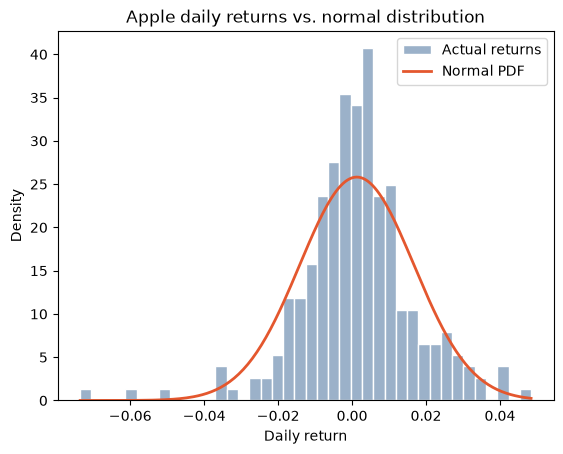

In [8]:
apple_returns = AAPL["Close"]["AAPL"].pct_change().dropna()
print(apple_returns)

mu = apple_returns.mean()
sigma = apple_returns.std()

# Actual return distribution (density=True puts it on the same scale as the PDF)
plt.hist(apple_returns, bins=40, density=True, color="#9bb1c9", edgecolor="white", label="Actual returns")
        
# Theoretical normal with the SAME mean & std
x = np.linspace(apple_returns.min(), apple_returns.max(), 200)
plt.plot(x, norm.pdf(x, mu, sigma), color="#e4572e", linewidth=2, label="Normal PDF")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.title("Apple daily returns vs. normal distribution")
plt.legend()
plt.show()



## Risk Premium and Risk Aversion
The risk premium is a "reward" measured as the HPR minus the risk-free rate ($r_f$), which is the rate you get on U.S. Treasury bonds. A positive risk premium distinguishes speculation from gambling.

Using the established theory, we want to get a grip of what risk aversion is. It can be inferred by comparing the risk premium, $E(r_C) - r_f$, of an investor's complete portfolio $C$ against the variance of the portfolio's return, $\sigma_C^2$:

$$
A = \frac{E(r_C) - r_f}{\sigma_C^2} \tag{5.14}
$$

We call this the price of risk.

In [12]:
# Risk-free rate (annual). Placeholder for now.
# TODO: replace with a real value from FRED (e.g. DGS3MO / TB3MS) in step 3.
rf = 0.04

def RiskPremium(Er, rf):
    """Reward for taking risk: expected return minus the risk-free rate."""
    return Er - rf

def RiskAversion(Er, rf, variance):
    """Infer A from a complete portfolio C (eq. 5.14), assuming it is fully invested (y = 1)."""
    return (Er - rf) / variance

# Use Apple's scenario stats as the risky portfolio (annual units, matching rf)
rp_Apple = RiskPremium(Er_Apple, rf)
A_Apple  = RiskAversion(Er_Apple, rf, var_Apple)

print(f"Risk premium (Apple):                  {rp_Apple:.2%}")
print(f"Implied risk aversion A (Apple, y=1):  {A_Apple:.2f}")

Risk premium (Apple):                  4.50%
Implied risk aversion A (Apple, y=1):  1.39


## The Sharpe Ratio
Now we obtain the big result of this chapter — the Sharpe ratio. It is used to rank portfolios in terms of their risk–return trade-off.

$$
S = \frac{\text{Portfolio risk premium}}{\text{SD of portfolio excess return}} = \frac{E(r_P) - r_f}{\sigma_P} \tag{5.16}
$$

A larger value of $S$ indicates a higher reward per unit of standard deviation, which in other words implies a more efficient portfolio.

> **TODO:** explain how this is related to mean–variance analysis.

In [13]:
def SharpeRatio(Er, rf, sd):
    """Reward per unit of total risk (eq. 5.16): excess return divided by standard deviation."""
    return (Er - rf) / sd

S_Apple     = SharpeRatio(Er_Apple, rf, sd_Apple)
S_Microsoft = SharpeRatio(Er_Microsoft, rf, sd_Microsoft)

print(f"Sharpe ratio Apple:     {S_Apple:.3f}")
print(f"Sharpe ratio Microsoft: {S_Microsoft:.3f}")

better = "Apple" if S_Apple > S_Microsoft else "Microsoft"
print(f"\nHigher Sharpe = better reward per unit of risk -> {better} is more efficient here.")

Sharpe ratio Apple:     0.250
Sharpe ratio Microsoft: 0.244

Higher Sharpe = better reward per unit of risk -> Apple is more efficient here.


## The Historical Record
**Using a time series of returns:** with a sample of $n$ observations, we multiply our estimate of variance by the ratio $\tfrac{n}{n-1}$.

$$
\hat{r} = \frac{1}{n}\sum_{t=1}^{n} r_t
$$

$$
\operatorname{Var}(r_t) = \frac{1}{n-1}\sum_{t=1}^{n}\bigl(r_t - \hat{r}\bigr)^2
$$

$$
\operatorname{SD}(r_t) = \sqrt{\operatorname{Var}(r_t)} \tag{5.17}
$$

> **TODO:** write what we use this for.

## Asset Allocation Across Risky and Risk-Free Portfolios
**Portfolio expected return and risk.** You want to determine the fraction of the complete portfolio to allocate to the risky portfolio. First you must determine the expected return and risk **corresponding to any possible allocation**.

Notation:
- $P$ — the risky portfolio
- $y$ — budget fraction allocated to $P$
- $(1 - y)$ — the risk-free proportion
- $r_P$ — actual rate of return on $P$
- $E(r_P)$ — expected rate of return
- $\sigma_P$ — standard deviation of $P$

The **risk premium** of the complete portfolio $C$:

$$
E(r_C) - r_f = y\,\bigl(E(r_P) - r_f\bigr) \tag{5.18}
$$

The standard deviation of $C$:

$$
\sigma_C = y\,\sigma_P \tag{5.19}
$$

> **TODO:** explain why we do not need the SD of the risk-free asset $f$, since it is risk-free.

### The Capital Allocation Line (CAL)
The slope $S$ of the CAL equals the increase in expected return an investor obtains per unit of additional standard deviation — which is exactly the Sharpe ratio.

To find $y$, we divide the risky portfolio's price of risk by the investor's risk aversion:

$$
y^{*} = \frac{E(r_P) - r_f}{A\,\sigma_P^{2}}
$$

Optimal weight in Apple (risky):  46.19%
Weight in risk-free asset:        53.81%
Complete portfolio  E(r_C) = 6.08%,   SD = 8.32%

CAL slope (risk premium / SD): 0.250
Apple Sharpe ratio:            0.250


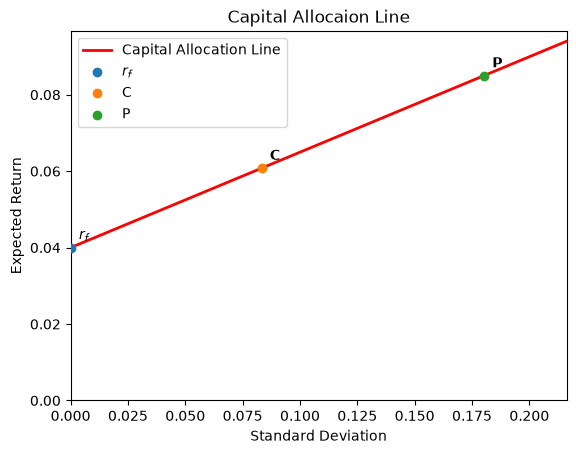

In [42]:
def CompletePortfolio(Er_P, sd_P, rf, y):
    """E(r) and SD of the complete portfolio C for a given risky weight y (eq. 5.18-5.19).

    The risk-free asset contributes return but no volatility, which is why
    only the risky portfolio's SD enters sd_C.
    """
    Er_C = rf + y * (Er_P - rf)     # rf + risk premium of C
    sd_C = y * sd_P                 # risk-free asset adds no risk
    return Er_C, sd_C

def OptimalRiskyWeight(Er_P, rf, A, var_P):
    """Utility-maximising fraction in the risky portfolio (CAL): y* = (E(rP) - rf) / (A * var_P)."""
    return (Er_P - rf) / (A * var_P)

# Here A is an INPUT (the investor's risk aversion), unlike eq. 5.14 where we inferred it.
A = 3.0

y_star     = OptimalRiskyWeight(Er_Apple, rf, A, var_Apple)
Er_C, sd_C = CompletePortfolio(Er_Apple, sd_Apple, rf, y_star)

print(f"Optimal weight in Apple (risky):  {y_star:.2%}")
print(f"Weight in risk-free asset:        {1 - y_star:.2%}")
print(f"Complete portfolio  E(r_C) = {Er_C:.2%},   SD = {sd_C:.2%}")

# Sanity check: at the optimum, the CAL slope equals Apple's Sharpe ratio.
print(f"\nCAL slope (risk premium / SD): {(Er_C - rf) / sd_C:.3f}")
print(f"Apple Sharpe ratio:            {SharpeRatio(Er_Apple, rf, sd_Apple):.3f}")

x = np.linspace(0, sd_Apple*1.2, 100)
plt.plot(x, rf + S_Apple*x, color="red", linewidth=2, label="Capital Allocation Line")
plt.xlabel("Standard Deviation")
plt.ylabel("Expected Return")
plt.xlim(0, sd_Apple*1.2)
plt.ylim(bottom=0)

# plt.scatter(sd_C, Er_C, color = "blue", zorder=10, label=f"Chosen portfolio (y* = {y_star:.0%})") # the chosen portfolio point
# plt.scatter(sd_Apple, Er_Apple, color="black", zorder=5,label="Risky portfolio P (only Apple)")
# plt.scatter(0, rf, color="black", zorder=5, label="Risk-free asset")

points = [
      ("$r_f$", 0,        rf),
      ("C",     sd_C,     Er_C),      # your chosen portfolio
      ("P",     sd_Apple, Er_Apple),  # the risky asset
  ]

for name, sd, er in points:
      plt.scatter(sd, er, zorder=5, label = name)
      plt.annotate(name, xy=(sd, er),
                   xytext=(6, 6), textcoords="offset points", fontweight="bold")


plt.title("Capital Allocaion Line")

plt.legend()
plt.show()